<a href="https://colab.research.google.com/github/nashlypilar-collab/Intro_ciencia_tarea_grupo/blob/main/FraudesTDC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Carga y Lectura del DataFrame**

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
duckdb.register("transacciones", df)
import sqlite3
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df = pd.read_csv("/content/credit_card_fraud_2026.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [ ]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,0


Optativa para eliminar

CATEGÓRICAS / NOMINALES:

- transaction_id
- merchant_category
- card_type
- auth_method
- channel
- device_type


ORDINALES:


NUMÉRICAS:
- amount_usd
- hours_since_last_txn
- txn_count_last_24h
- distance_from_home_km
- card_age_months
- customer_age
- account_balance_usd


BOOLEANAS:
- is_foreign_transaction
- is_new_merchant
- used_vpn
- ip_country_mismatch
- billing_shipping_mismatch
- billing_shipping_mismatch


In [ ]:
df.select_dtypes(include=['number']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         20000 non-null  int64  
 1   amount_usd             20000 non-null  float64
 2   hours_since_last_txn   20000 non-null  float64
 3   txn_count_last_24h     20000 non-null  int64  
 4   distance_from_home_km  20000 non-null  float64
 5   card_age_months        20000 non-null  int64  
 6   customer_age           20000 non-null  int64  
 7   account_balance_usd    20000 non-null  float64
 8   cvv_retry_count        20000 non-null  int64  
 9   velocity_score         20000 non-null  float64
 10  time_of_day_hour       20000 non-null  int64  
 11  day_of_week            20000 non-null  int64  
 12  merchant_risk_score    20000 non-null  float64
 13  prior_disputes         20000 non-null  int64  
 14  is_fraud               20000 non-null  int64  
dtypes:

CASTEAR

**- transaction_id (NOMINAL)**
- merchant_category (NOMINAL)
- card_type (NOMINAL)
- auth_method (NOMINAL)
- channel (NOMINAL)
- device_type (NOMINAL)

**- cvv_retry_count (ORDINAL)**
**- day_of_week (ORDINAL)**
**- prior_disputes (ORDINAL)**

- is_fraud (BOOL)



In [ ]:
df.select_dtypes(include=['bool']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   is_foreign_transaction        20000 non-null  bool 
 1   is_new_merchant               20000 non-null  bool 
 2   used_vpn                      20000 non-null  bool 
 3   ip_country_mismatch           20000 non-null  bool 
 4   billing_shipping_mismatch     20000 non-null  bool 
 5   is_ai_generated_scam_attempt  20000 non-null  bool 
dtypes: bool(6)
memory usage: 117.3 KB


In [ ]:
df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   merchant_category  20000 non-null  object
 1   card_type          20000 non-null  object
 2   auth_method        20000 non-null  object
 3   channel            20000 non-null  object
 4   device_type        20000 non-null  object
dtypes: object(5)
memory usage: 781.4+ KB


### **Casteo de Variables**

In [ ]:
## Convertir a Booleana

df['is_fraud'] = df['is_fraud'].astype(bool)

In [ ]:
#Eliminar

df.select_dtypes(include=['bool']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   is_foreign_transaction        20000 non-null  bool 
 1   is_new_merchant               20000 non-null  bool 
 2   used_vpn                      20000 non-null  bool 
 3   ip_country_mismatch           20000 non-null  bool 
 4   billing_shipping_mismatch     20000 non-null  bool 
 5   is_ai_generated_scam_attempt  20000 non-null  bool 
 6   is_fraud                      20000 non-null  bool 
dtypes: bool(7)
memory usage: 136.8 KB


In [ ]:
# Convertir variables a category

nominales = ["transaction_id", "merchant_category", "card_type", "auth_method", "channel", "device_type"]
df[nominales] = df[nominales].astype("category")


In [ ]:
# Convertir numéricas en categoricas ordinales
df["cvv_retry_count"] = pd.Categorical(
    df["cvv_retry_count"],
    categories=[0, 1, 2, 3],
    ordered=True
)

In [ ]:
df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=[0, 1, 2, 3, 4, 5, 6],
    ordered=True
)

In [ ]:
df["prior_disputes"] = pd.Categorical(
    df["prior_disputes"],
    categories=[0, 1, 2, 3, 4],
    ordered=True
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   transaction_id                20000 non-null  category
 1   amount_usd                    20000 non-null  float64 
 2   merchant_category             20000 non-null  category
 3   card_type                     20000 non-null  category
 4   auth_method                   20000 non-null  category
 5   channel                       20000 non-null  category
 6   device_type                   20000 non-null  category
 7   is_foreign_transaction        20000 non-null  bool    
 8   hours_since_last_txn          20000 non-null  float64 
 9   txn_count_last_24h            20000 non-null  int64   
 10  distance_from_home_km         20000 non-null  float64 
 11  card_age_months               20000 non-null  int64   
 12  customer_age                  20000 non-null  

In [ ]:
len(df)

20000

In [ ]:
# Resumen categórico
print('\nResumen numérico:')
display(df.describe())

print('\nResumen categórico:')
display(df.describe(include='category'))

print('\nResumen categórico:')
display(df.describe(include='bool'))


Resumen numérico:


,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,velocity_score,time_of_day_hour,merchant_risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,19.807735,11.533650,37.400390
std,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,12.366301,6.925335,17.061415
min,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000
25%,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,10.700000,6.000000,25.600000
50%,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,18.800000,12.000000,35.700000
75%,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,27.600000,18.000000,47.300000
max,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,74.400000,23.000000,100.000000



Resumen categórico:


,transaction_id,merchant_category,card_type,auth_method,channel,device_type,cvv_retry_count,day_of_week,prior_disputes
count,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,20000,12,5,5,5,8,4,7,5
top,19984,Online Retail,Visa,3D Secure,Online,Android Phone,0,6,0
freq,1,3416,8417,5554,6810,5503,16658,2921,15085



Resumen categórico:


,is_foreign_transaction,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,is_ai_generated_scam_attempt,is_fraud
count,20000,20000,20000,20000,20000,20000,20000
unique,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False
freq,18760,15399,18241,18834,19127,19625,19661


In [ ]:
#Eliminar y mejor ponerlo como conclusión al validar el .info()
df.isnull().sum()

,0
transaction_id,0
amount_usd,0
merchant_category,0
card_type,0
auth_method,0
channel,0
device_type,0
is_foreign_transaction,0
hours_since_last_txn,0
txn_count_last_24h,0


Se reconfirma que no el data set no tiene datos nulos

### **Validación de valore únicos**

In [ ]:
df.nunique(dropna=False)

,0
transaction_id,20000
amount_usd,12782
merchant_category,12
card_type,5
auth_method,5
channel,5
device_type,8
is_foreign_transaction,2
hours_since_last_txn,3296
txn_count_last_24h,13


In [ ]:
df_fraude = df.copy()

In [ ]:
df_fraude.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,False
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,False
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,False
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,False
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,False


In [ ]:
conn = sqlite3.connect(":memory:")

df_fraude.to_sql("df_fraude", conn, index=False, if_exists="replace")

def run_sql(query):
    return pd.read_sql_query(query, conn)

# **Análisis de variables**

**1. Total de transacciones y porcentaje de fraude**

In [ ]:
total = len(df_fraude)
fraudes = int(df_fraude["is_fraud"].sum())
no_fraudes = total - fraudes

porcentaje_fraude = 100 * fraudes / total
porcentaje_no_fraude = 100 * no_fraudes / total

resumen = pd.DataFrame({
    "Tipo de transacción": ["Fraude", "No fraude", "Total"],
    "Cantidad": [fraudes, no_fraudes, total],
    "Porcentaje": [
        round(porcentaje_fraude, 2),
        round(porcentaje_no_fraude, 2),
        100.00
    ]
})

display(resumen)

,Tipo de transacción,Cantidad,Porcentaje
0,Fraude,339,1.70
1,No fraude,19661,98.31
2,Total,20000,100.00


Del 100% de las transacciones, el 1.7% es fraude

**2. Distribución por monto**

In [ ]:
# Conservar únicamente las operaciones marcadas como fraude
df_solo_fraudes = df_fraude[df_fraude["is_fraud"] == True].copy()

nombres_cuartiles = ["Bajo", "Medio", "Alto", "Muy Alto"]

# Dividir los montos de las operaciones fraudulentas en cuatro cuartiles
df_solo_fraudes["montos_fraude"] = pd.qcut(
    df_solo_fraudes["amount_usd"],
    q=4,
    labels=nombres_cuartiles,
    duplicates="drop"
)

# Resumir los rangos de monto de las operaciones fraudulentas
tabla_montos = (
    df_solo_fraudes.groupby("montos_fraude", observed=False)
    .agg(
        cantidad=("amount_usd", "size"),
        monto_min=("amount_usd", "min"),
        monto_max=("amount_usd", "max")
    )
    .reindex(nombres_cuartiles)
)

display(tabla_montos.round(2))

,cantidad,monto_min,monto_max
montos_fraude,,,
Bajo,85,4.09,28.26
Medio,85,28.98,69.77
Alto,84,70.38,164.42
Muy Alto,85,166.22,3356.46


La variable amount_usd se agrupó en cuatro rangos ordenados: Bajo, Medio, Alto y Muy Alto. La tabla muestra los límites de monto de cada rango.

**Variable 2 - SQL**

In [274]:
query_2 = """
WITH fraudes AS (
    SELECT amount_usd
    FROM df_fraude
    WHERE is_fraud = 1
),
montos_numerados AS (
    SELECT
        amount_usd,
        NTILE(4) OVER (ORDER BY amount_usd) AS cuartil
    FROM fraudes
)
SELECT
    CASE cuartil
        WHEN 1 THEN 'Bajo'
        WHEN 2 THEN 'Medio'
        WHEN 3 THEN 'Alto'
        WHEN 4 THEN 'Muy Alto'
    END AS montos_fraude,
    COUNT(*) AS cantidad,
    MIN(amount_usd) AS monto_min,
    MAX(amount_usd) AS monto_max
FROM montos_numerados
GROUP BY cuartil
ORDER BY cuartil;
"""

sql_1 = run_sql(query_2)
sql_1

,montos_fraude,cantidad,monto_min,monto_max
0,Bajo,85,4.09,28.26
1,Medio,85,28.98,69.77
2,Alto,85,70.38,166.22
3,Muy Alto,84,167.67,3356.46


**3. Relación entre los rangos de monto y el fraude**

,cantidad,fraudes,porcentaje_fraude,porcentaje_del_total_de_fraudes
montos_fraude,,,,
Bajo,5000,79,1.58,23.30
Medio,5001,78,1.56,23.01
Alto,4999,73,1.46,21.53
Muy Alto,5000,109,2.18,32.15


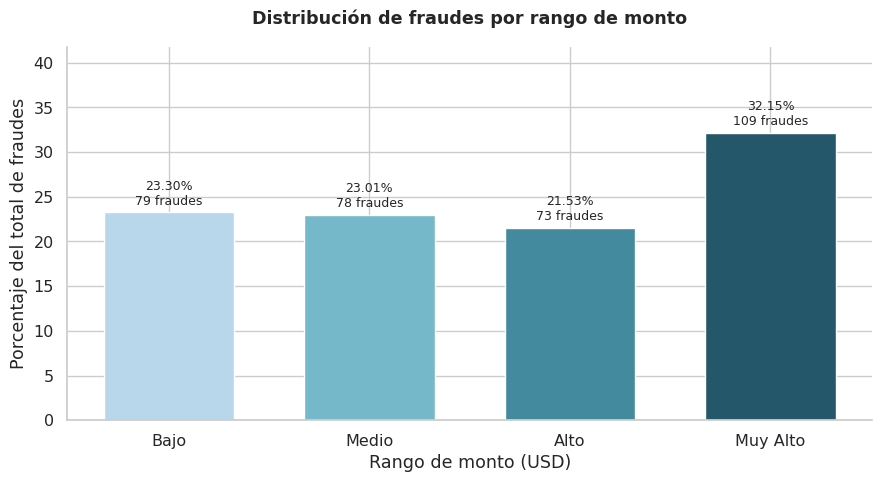

In [ ]:
# Calcular qué porcentaje del total de fraudes corresponde a cada rango
total_fraudes = tabla_monto_fraude["fraudes"].sum()

tabla_monto_fraude["porcentaje_del_total_de_fraudes"] = (
    tabla_monto_fraude["fraudes"] / total_fraudes * 100
)

display(tabla_monto_fraude.round(2))

# Gráfico de la distribución de fraudes por rango de monto
sns.set_theme(style="whitegrid", font_scale=1.05)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#B9D7EA", "#75B8C9", "#438A9E", "#24576A"]

barras = ax.bar(
    nombres_cuartiles,
    tabla_monto_fraude.loc[
        nombres_cuartiles, "porcentaje_del_total_de_fraudes"
    ],
    color=colores,
    width=0.65
)

for barra, grupo in zip(barras, nombres_cuartiles):
    porcentaje = tabla_monto_fraude.loc[
        grupo, "porcentaje_del_total_de_fraudes"
    ]
    fraudes = tabla_monto_fraude.loc[grupo, "fraudes"]

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{porcentaje:.2f}%\n{fraudes} fraudes",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Distribución de fraudes por rango de monto",
    pad=16,
    weight="bold"
)
ax.set_xlabel("Rango de monto (USD)")
ax.set_ylabel("Porcentaje del total de fraudes")
ax.set_ylim(
    0,
    tabla_monto_fraude["porcentaje_del_total_de_fraudes"].max() * 1.3
)

sns.despine()
plt.tight_layout()
plt.show()

De los 339 fraudes, 109 (32,15 %) ocurrieron en el rango de monto Muy Alto. En los rangos Bajo, Medio y Alto hubo 79 (23,30 %), 78 (23,01 %) y 73 (21,53 %), respectivamente. Así, en esta gráfica, el grupo Muy Alto reúne la mayor parte de los fraudes.

**4. Variables temporales, relacionar días y horas de la transacción y por indicador de fraude (is_fraude)**

,day_of_week,dia_nombre,time_of_day_hour,transacciones,fraudes,porcentaje_fraude
0,0,Lunes,0,112,3,2.68
1,0,Lunes,1,123,1,0.81
2,0,Lunes,2,112,8,7.14
3,0,Lunes,3,109,3,2.75
4,0,Lunes,4,133,3,2.26
...,...,...,...,...,...,...
163,6,Domingo,19,126,3,2.38
164,6,Domingo,20,126,1,0.79
165,6,Domingo,21,115,0,0.00
166,6,Domingo,22,114,3,2.63


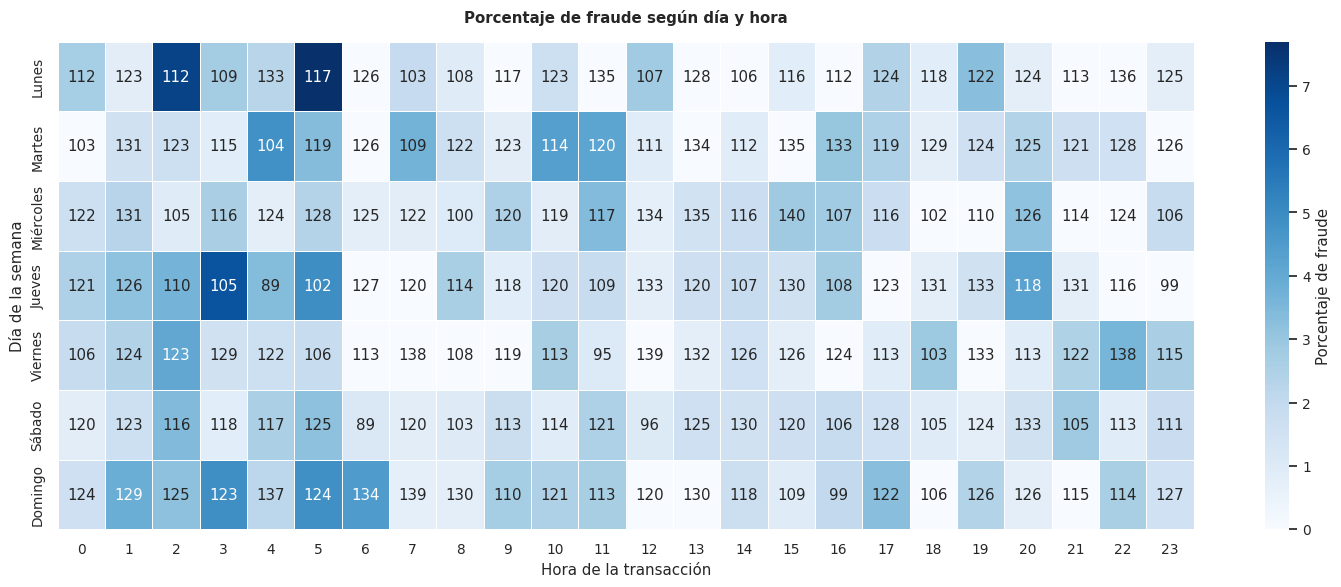

In [ ]:
orden_dias = list(dias_de_la_semana.values())

# Crear una copia temporal con los nombres de los días
df_tiempo = df_fraude.assign(
    dia_nombre=df_fraude["day_of_week"].astype(int).map(dias_de_la_semana)
)

# Calcular transacciones y fraudes por día y hora
tabla_tiempo = (
    df_tiempo.groupby(
        ["day_of_week", "dia_nombre", "time_of_day_hour"],
        observed=True
    )
    .agg(
        transacciones=("is_fraud", "size"),
        fraudes=("is_fraud", "sum")
    )
    .reset_index()
)

tabla_tiempo["porcentaje_fraude"] = (
    100 * tabla_tiempo["fraudes"] / tabla_tiempo["transacciones"]
)

display(tabla_tiempo.round(2))

# Preparar matrices para el mapa de calor
tasas = (
    tabla_tiempo.pivot(
        index="dia_nombre",
        columns="time_of_day_hour",
        values="porcentaje_fraude"
    )
    .reindex(orden_dias)
)

cantidades = (
    tabla_tiempo.pivot(
        index="dia_nombre",
        columns="time_of_day_hour",
        values="transacciones"
    )
    .reindex(orden_dias)
)

# Mostrar la cantidad de transacciones en cada cuadro
anotaciones = cantidades.fillna(0).astype(int).astype(str)
anotaciones = anotaciones.mask(cantidades.isna(), "")

# Crear el mapa de calor azul
sns.set_theme(style="white", font_scale=0.9)

plt.figure(figsize=(15, 6))
sns.heatmap(
    tasas,
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    annot=anotaciones,
    fmt="",
    cbar_kws={"label": "Porcentaje de fraude"}
)

plt.title("Porcentaje de fraude según día y hora", weight="bold", pad=14)
plt.xlabel("Hora de la transacción")
plt.ylabel("Día de la semana")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

En este conjunto de datos, la proporción de transacciones marcadas como fraude cambia un poco según el día y la hora. Al sumar todas las horas, el domingo tuvo la proporción más alta: 61 de 2.921 transacciones (2,09 %). El viernes tuvo la más baja: 40 de 2.880 (1,39 %). En el mapa también destacan algunas horas, como las 2:00 y las 5:00 del lunes. Esto sugiere que hay ciertas combinaciones de día y hora con más fraude en estos datos, aunque las diferencias son pequeñas y no se repite un mismo patrón durante todos los días.

**Variable 4 - SQL**


In [273]:
query_4 = """
SELECT
    day_of_week,
    CASE day_of_week
        WHEN 0 THEN 'Lunes'
        WHEN 1 THEN 'Martes'
        WHEN 2 THEN 'Miércoles'
        WHEN 3 THEN 'Jueves'
        WHEN 4 THEN 'Viernes'
        WHEN 5 THEN 'Sábado'
        WHEN 6 THEN 'Domingo'
    END AS dia_nombre,
    time_of_day_hour AS hora,
    COUNT(*) AS transacciones,
    SUM(CASE WHEN is_fraud = 1 THEN 1 ELSE 0 END) AS fraudes,
    ROUND(
        100.0 * SUM(CASE WHEN is_fraud = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS porcentaje_fraude
FROM df_fraude
GROUP BY day_of_week, time_of_day_hour
ORDER BY day_of_week, time_of_day_hour;
"""

sql_4 = run_sql(query_4)
display(sql_4)

,day_of_week,dia_nombre,hora,transacciones,fraudes,porcentaje_fraude
0,0,Lunes,0,112,3,2.68
1,0,Lunes,1,123,1,0.81
2,0,Lunes,2,112,8,7.14
3,0,Lunes,3,109,3,2.75
4,0,Lunes,4,133,3,2.26
...,...,...,...,...,...,...
163,6,Domingo,19,126,3,2.38
164,6,Domingo,20,126,1,0.79
165,6,Domingo,21,115,0,0.00
166,6,Domingo,22,114,3,2.63


**5. Tasa de fraude por canal de transacción**

,transacciones,fraudes,porcentaje_fraude_en_canal,porcentaje_del_total_de_fraudes
channel,,,,
ATM,1374,25,1.82,7.37
Contactless,3400,48,1.41,14.16
In-App,3225,52,1.61,15.34
Online,6810,135,1.98,39.82
POS,5191,79,1.52,23.30


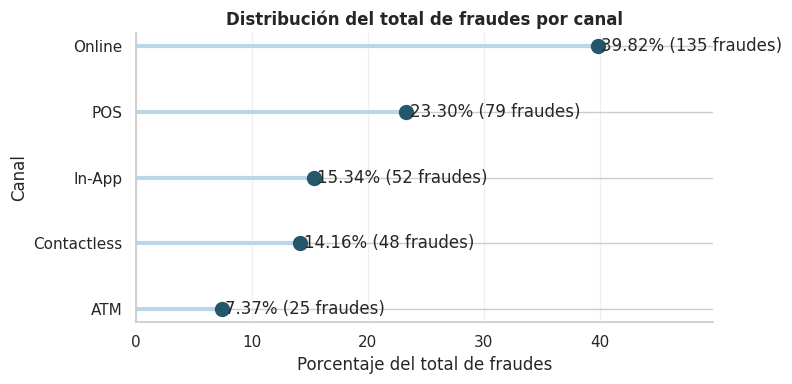

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular transacciones y fraudes por canal
tabla_canal = (
    df_fraude.groupby("channel", observed=True)
    .agg(
        transacciones=("is_fraud", "size"),
        fraudes=("is_fraud", "sum")
    )
)

# Tasa de fraude dentro de cada canal
tabla_canal["porcentaje_fraude_en_canal"] = (
    100 * tabla_canal["fraudes"] / tabla_canal["transacciones"]
)

# Porcentaje que representa cada canal del total de fraudes
total_fraudes = tabla_canal["fraudes"].sum()

tabla_canal["porcentaje_del_total_de_fraudes"] = (
    100 * tabla_canal["fraudes"] / total_fraudes
)

display(tabla_canal.round(2))

# Ordenar los canales por su porcentaje del total de fraudes
tabla_grafico = tabla_canal.sort_values(
    "porcentaje_del_total_de_fraudes"
)

# Crear gráfico de puntos
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 4))
posiciones = range(len(tabla_grafico))

ax.hlines(
    y=posiciones,
    xmin=0,
    xmax=tabla_grafico["porcentaje_del_total_de_fraudes"],
    color="#B9D7EA",
    linewidth=3
)

ax.scatter(
    tabla_grafico["porcentaje_del_total_de_fraudes"],
    posiciones,
    color="#24576A",
    s=100,
    zorder=3
)

ax.set_yticks(list(posiciones))
ax.set_yticklabels(tabla_grafico.index)
ax.set_xlabel("Porcentaje del total de fraudes")
ax.set_ylabel("Canal")
ax.set_title(
    "Distribución del total de fraudes por canal",
    weight="bold"
)
ax.set_xlim(
    0,
    tabla_grafico["porcentaje_del_total_de_fraudes"].max() * 1.25
)
ax.grid(axis="x", alpha=0.3)

for posicion, (_, fila) in enumerate(tabla_grafico.iterrows()):
    ax.text(
        fila["porcentaje_del_total_de_fraudes"] + 0.3,
        posicion,
        f'{fila["porcentaje_del_total_de_fraudes"]:.2f}% '
        f'({int(fila["fraudes"])} fraudes)',
        va="center"
    )

sns.despine()
plt.tight_layout()
plt.show()

De los 339 fraudes, la mayor parte ocurrió en el canal Online: 135 casos (39,82 %). Le sigue POS, con 79 casos (23,30 %). Después aparecen In-App, con 52 (15,34 %); Contactless, con 48 (14,16 %); y ATM, con 25 (7,37 %).
Esto indica cómo se reparten los casos de fraude entre los canales. No significa que Online tenga la mayor tasa de fraude por transacción, sino que reúne la mayor parte de los fraudes registrados.

**6. Porcentaje de fraude por canal y condición extranjera**

/tmp/ipykernel_4164/2071789032.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_canal_extranjero.groupby(level="channel")["fraudes"]


transacciones  fraudes  porcentaje_fraude  porcentaje_de_fraudes_del_canal
channel     tipo_transaccion                                                                                     
ATM         Transacción internacional             89        3               3.37                            12.00
            Transacción nacional                1285       22               1.71                            88.00
Contactless Transacción internacional            198       11               5.56                            22.92
            Transacción nacional                3202       37               1.16                            77.08
In-App      Transacción internacional            205       12               5.85                            23.08
            Transacción nacional                3020       40               1.32                            76.92
Online      Transacción internacional            419       24               5.73                            17.78
            Transacción nacional                6391      111               1.74                            82.22
POS         Transacción internacional            329       23               6.99                            29.11
            Transacción nacional                4862       56               1.15                            70.89

,fraudes,porcentaje_del_total_de_fraudes
tipo_transaccion,,
Transacción nacional,266,78.47
Transacción internacional,73,21.53


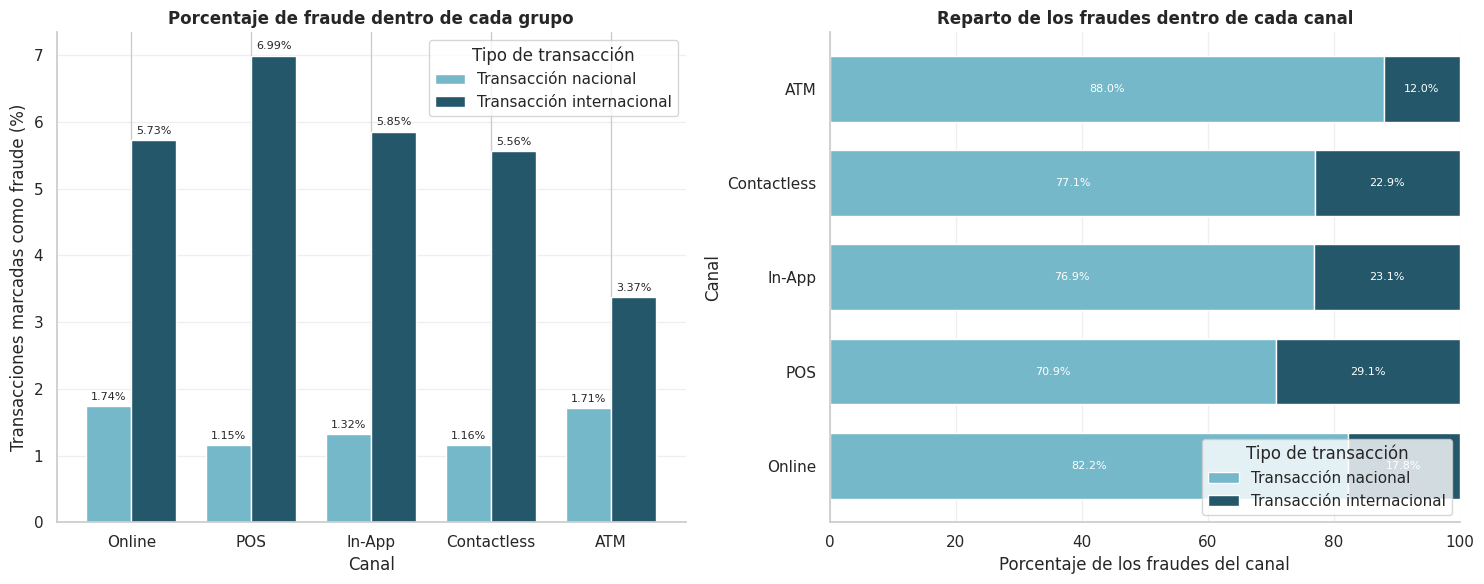

In [ ]:

# Etiquetar las transacciones sin modificar df_fraude
df_canal_extranjero = df_fraude.assign(
    tipo_transaccion=df_fraude["is_foreign_transaction"].map({
        False: "Transacción nacional",
        True: "Transacción internacional"
    })
)

# Resumir por canal y tipo de transacción
tabla_canal_extranjero = (
    df_canal_extranjero
    .groupby(["channel", "tipo_transaccion"], observed=True)
    .agg(
        transacciones=("is_fraud", "size"),
        fraudes=("is_fraud", "sum")
    )
)

# Porcentaje de fraude dentro de cada grupo
tabla_canal_extranjero["porcentaje_fraude"] = (
    100 * tabla_canal_extranjero["fraudes"]
    / tabla_canal_extranjero["transacciones"]
)

# Porcentaje de los fraudes de cada canal que corresponde a cada tipo
total_fraudes_por_canal = (
    tabla_canal_extranjero.groupby(level="channel")["fraudes"]
    .transform("sum")
)

tabla_canal_extranjero["porcentaje_de_fraudes_del_canal"] = (
    100 * tabla_canal_extranjero["fraudes"]
    / total_fraudes_por_canal
)

display(tabla_canal_extranjero.round(2))

# Porcentaje nacional e internacional del total de fraudes
resumen_total_fraudes = (
    df_canal_extranjero[df_canal_extranjero["is_fraud"]]
    ["tipo_transaccion"]
    .value_counts()
    .rename_axis("tipo_transaccion")
    .to_frame("fraudes")
)

resumen_total_fraudes["porcentaje_del_total_de_fraudes"] = (
    100 * resumen_total_fraudes["fraudes"]
    / resumen_total_fraudes["fraudes"].sum()
)

display(resumen_total_fraudes.round(2))

# Preparar tablas para los gráficos
orden_canales = list(df_fraude["channel"].dropna().unique())
orden_tipos = ["Transacción nacional", "Transacción internacional"]

tasas = (
    tabla_canal_extranjero["porcentaje_fraude"]
    .unstack("tipo_transaccion")
    .reindex(index=orden_canales, columns=orden_tipos)
)

composicion_fraudes = (
    tabla_canal_extranjero["porcentaje_de_fraudes_del_canal"]
    .unstack("tipo_transaccion")
    .reindex(index=orden_canales, columns=orden_tipos)
)

# Crear dos gráficos complementarios
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colores = {
    "Transacción nacional": "#75B8C9",
    "Transacción internacional": "#24576A"
}

# Gráfico 1: tasa de fraude dentro de cada grupo
tasas.plot(
    kind="bar",
    ax=axes[0],
    color=[colores[tipo] for tipo in orden_tipos],
    width=0.75
)

axes[0].set_title("Porcentaje de fraude dentro de cada grupo", weight="bold")
axes[0].set_xlabel("Canal")
axes[0].set_ylabel("Transacciones marcadas como fraude (%)")
axes[0].legend(title="Tipo de transacción")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

for contenedor in axes[0].containers:
    etiquetas = [
        f"{barra.get_height():.2f}%" if barra.get_height() > 0 else ""
        for barra in contenedor
    ]
    axes[0].bar_label(contenedor, labels=etiquetas, padding=3, fontsize=8)

# Gráfico 2: reparto de los fraudes dentro de cada canal
composicion_fraudes.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=[colores[tipo] for tipo in orden_tipos],
    width=0.7
)

axes[1].set_title("Reparto de los fraudes dentro de cada canal", weight="bold")
axes[1].set_xlabel("Porcentaje de los fraudes del canal")
axes[1].set_ylabel("Canal")
axes[1].set_xlim(0, 100)
axes[1].legend(title="Tipo de transacción", loc="lower right")
axes[1].grid(axis="x", alpha=0.3)

for contenedor in axes[1].containers:
    etiquetas = [
        f"{barra.get_width():.1f}%" if barra.get_width() >= 8 else ""
        for barra in contenedor
    ]
    axes[1].bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8,
        color="white"
    )

sns.despine()
plt.tight_layout()
plt.show()

En todos los canales, el porcentaje de transacciones marcadas como fraude fue mayor entre las internacionales que entre las nacionales. Por ejemplo, en POS (punto de venta, como el lector de tarjetas de una tienda), el fraude representó el 6,99 % de las transacciones internacionales y el 1,15 % de las nacionales.
Eso no significa que la mayoría de los fraudes fueran internacionales. De los 339 fraudes registrados en total, 73 (21,53 %) fueron transacciones internacionales y 266 (78,47 %) fueron nacionales. Como había muchas más transacciones nacionales en el dataset, estas sumaron más casos de fraude, aunque su porcentaje dentro del grupo fue menor.
En resumen: las transacciones internacionales tuvieron una proporción de fraude más alta, pero la mayoría de los casos registrados fueron nacionales.

**7. Porcentaje de fraude según reintentos de CVV y tipo de tarjeta**

,cvv_retry_count,card_type,transacciones,fraudes,porcentaje_fraude
0,0,Amex,1757,13,0.74
1,0,Discover,849,10,1.18
2,0,Mastercard,5525,42,0.76
3,0,RuPay,1487,14,0.94
4,0,Visa,7040,74,1.05
5,1,Amex,348,25,7.18
6,1,Discover,161,9,5.59
7,1,Mastercard,1022,48,4.70
8,1,RuPay,283,8,2.83
9,1,Visa,1259,53,4.21


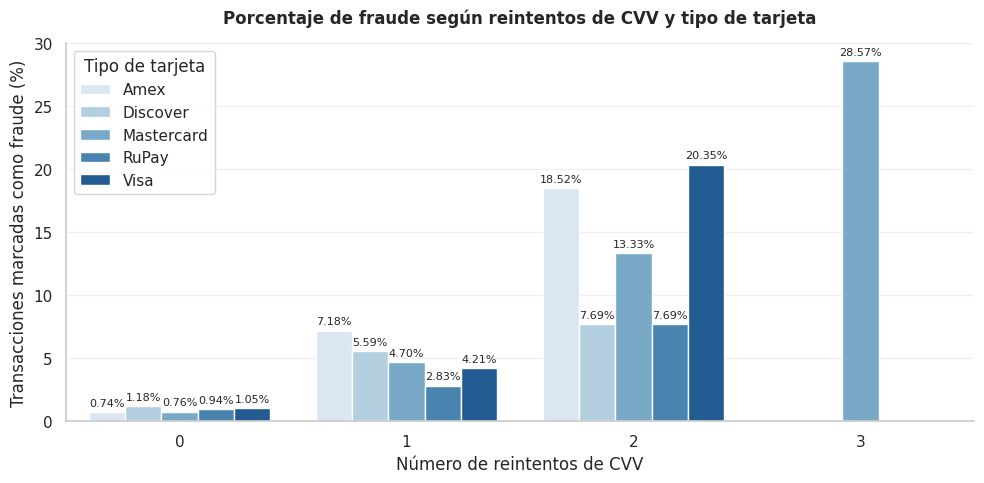

In [ ]:
# Contar todas las transacciones y cuántas fueron fraude
tabla_cvv_tarjeta = (
    df_fraude.groupby(
        ["cvv_retry_count", "card_type"],
        observed=True
    )
    .agg(
        transacciones=("is_fraud", "size"),
        fraudes=("is_fraud", "sum")
    )
    .reset_index()
)

# Calcular el porcentaje de fraude dentro de cada grupo
tabla_cvv_tarjeta["porcentaje_fraude"] = (
    100 * tabla_cvv_tarjeta["fraudes"]
    / tabla_cvv_tarjeta["transacciones"]
)

display(tabla_cvv_tarjeta.round(2))

# Graficar el porcentaje de fraude en tonos azules
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=tabla_cvv_tarjeta,
    x="cvv_retry_count",
    y="porcentaje_fraude",
    hue="card_type",
    palette="Blues",
    ax=ax
)

# Mostrar el porcentaje sobre cada barra
for grupo_barras in ax.containers:
    etiquetas = [
        f"{barra.get_height():.2f}%" if barra.get_height() > 0 else ""
        for barra in grupo_barras
    ]
    ax.bar_label(
        grupo_barras,
        labels=etiquetas,
        padding=3,
        fontsize=8
    )

ax.set_title(
    "Porcentaje de fraude según reintentos de CVV y tipo de tarjeta",
    weight="bold",
    pad=14
)
ax.set_xlabel("Número de reintentos de CVV")
ax.set_ylabel("Transacciones marcadas como fraude (%)")
ax.legend(title="Tipo de tarjeta")
ax.grid(axis="y", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

En estos datos, el porcentaje de transacciones marcadas como fraude suele aumentar cuando hay más reintentos de CVV. Con 0 reintentos, las tasas son bajas para todos los tipos de tarjeta: entre 0,74 % y 1,18 %. Con 1 reintento, las tasas van de 2,83 % a 7,18 %; con 2 reintentos, van de 7,69 % a 20,35 %.
Los porcentajes también varían según el tipo de tarjeta. Por ejemplo, con 2 reintentos, Visa tiene el porcentaje más alto (20,35 %). El valor más alto del gráfico es Mastercard con 3 reintentos (28,57 %), pero corresponde a solo 2 fraudes de 7 transacciones, así que debe tomarse con cautela.
En resumen, el gráfico sugiere que más reintentos aparecen asociados con una mayor proporción de fraude, y que las tasas varían entre tipos de tarjeta. Como algunos grupos tienen pocas transacciones, estos resultados describen el dataset y no permiten afirmar que los reintentos o el tipo de tarjeta causen fraude

**8. Rangos por cuartiles de hours_since_last_txn**

In [ ]:
df_fraude["rango_horas"] = pd.qcut(
    df_fraude["hours_since_last_txn"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df_fraude[["hours_since_last_txn", "rango_horas"]]

,hours_since_last_txn,rango_horas
0,13.54,Q4
1,0.71,Q1
2,0.35,Q1
3,3.42,Q2
4,2.43,Q1
...,...,...
19995,8.82,Q3
19996,45.81,Q4
19997,20.67,Q4
19998,22.94,Q4


9. Relación de los rangos de la última hora y fraude

In [ ]:
df_fraude["rango_horas"] = pd.qcut(
    df_fraude["hours_since_last_txn"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df_fraude[["hours_since_last_txn", "rango_horas"]]

,hours_since_last_txn,rango_horas
0,13.54,Q4
1,0.71,Q1
2,0.35,Q1
3,3.42,Q2
4,2.43,Q1
...,...,...
19995,8.82,Q3
19996,45.81,Q4
19997,20.67,Q4
19998,22.94,Q4


In [ ]:
duckdb.sql("""
SELECT
    hours_since_last_txn,
    NTILE(4) OVER (
        ORDER BY hours_since_last_txn
    ) AS rango_horas
FROM df_fraude
ORDER BY hours_since_last_txn
""")

┌──────────────────────┬─────────────┐
│ hours_since_last_txn │ rango_horas │
│        double        │    int64    │
├──────────────────────┼─────────────┤
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                   ·  │           · │
│                   ·  │           · │
│                   ·  │           · │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                 6.21 │           2 │
│                 6.21 │           2 │
│                 6.21 │ 

**9. Variable de relación de los rangos de la última hora y fraude**

In [ ]:
#variable de relación de los rangos de la última hora y fraude

resultado = pd.crosstab(
    df_fraude["rango_horas"],
    df_fraude["is_fraud"],
    normalize="index"
)[True] * 100

resultado.round(2)

,True
rango_horas,
Q1,2.51
Q2,1.52
Q3,1.46
Q4,1.28


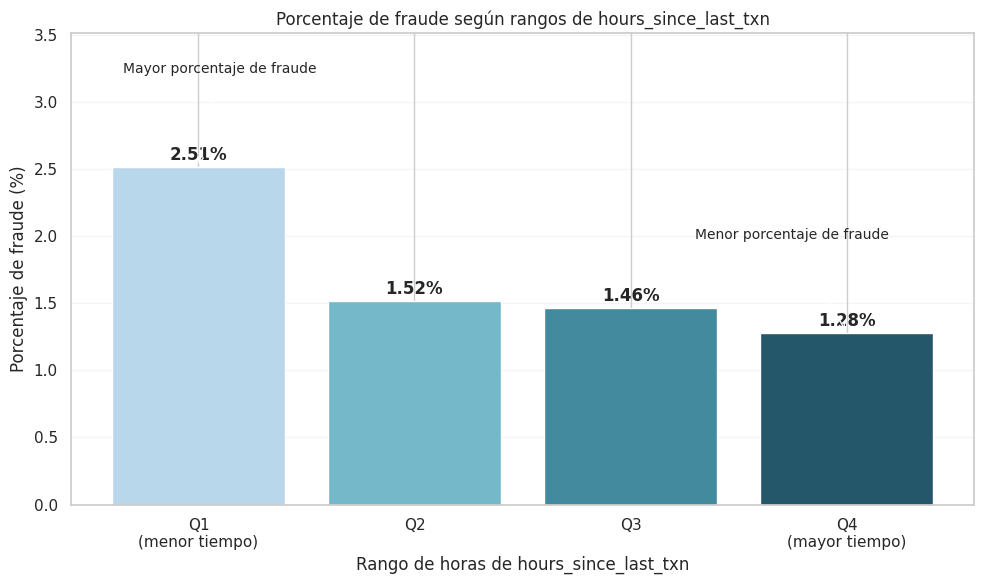

In [ ]:
import matplotlib.pyplot as plt

colores = ["#B9D7EA", "#75B8C9", "#438A9E", "#24576A"]

plt.figure(figsize=(10, 6))

barras = plt.bar(
    resultado.index,
    resultado.values,
    color=colores
)

plt.xlabel("Rango de horas de hours_since_last_txn")
plt.ylabel("Porcentaje de fraude (%)")
plt.title("Porcentaje de fraude según rangos de hours_since_last_txn")

for barra, valor in zip(barras, resultado.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.annotate(
    "Mayor porcentaje de fraude",
    xy=(0, resultado.iloc[0]),
    xytext=(-0.35, resultado.iloc[0] + 0.7),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.annotate(
    "Menor porcentaje de fraude",
    xy=(3, resultado.iloc[3]),
    xytext=(2.3, resultado.iloc[3] + 0.7),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xticks(
    range(4),
    ["Q1\n(menor tiempo)", "Q2", "Q3", "Q4\n(mayor tiempo)"]
)

plt.ylim(0, resultado.max() + 1)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

**10. Variable de transacciones en 24h por fraude**

In [ ]:
# Variable de transacciones en 24h por fraude

resultado_24h = df_fraude.groupby(
    "is_fraud"
)["txn_count_last_24h"].agg(
    ["count", "mean", "min", "max"]
).round(2)

resultado_24h

,count,mean,min,max
is_fraud,,,,
False,19661,3.18,0,11
True,339,4.00,0,12


Las transacciones fraudulentas presentan un promedio de 4,00 transacciones en las últimas 24 horas, mientras que las no fraudulentas presentan un promedio de 3,18. Además, el máximo es ligeramente mayor en las transacciones fraudulentas (12 frente a 11). Esto muestra que, en los datos analizados, las transacciones fraudulentas presentan una mayor cantidad promedio de transacciones recientes.

**11. Variable entre monto, edad del cliente y fraude**

In [ ]:
# variable entre monto, edad del cliente y fraude

resultado_corr = df_fraude[
    ["amount_usd", "customer_age", "is_fraud"]
].corr().round(2)

resultado_corr

,amount_usd,customer_age,is_fraud
amount_usd,1.00,-0.01,0.02
customer_age,-0.01,1.00,0.02
is_fraud,0.02,0.02,1.00


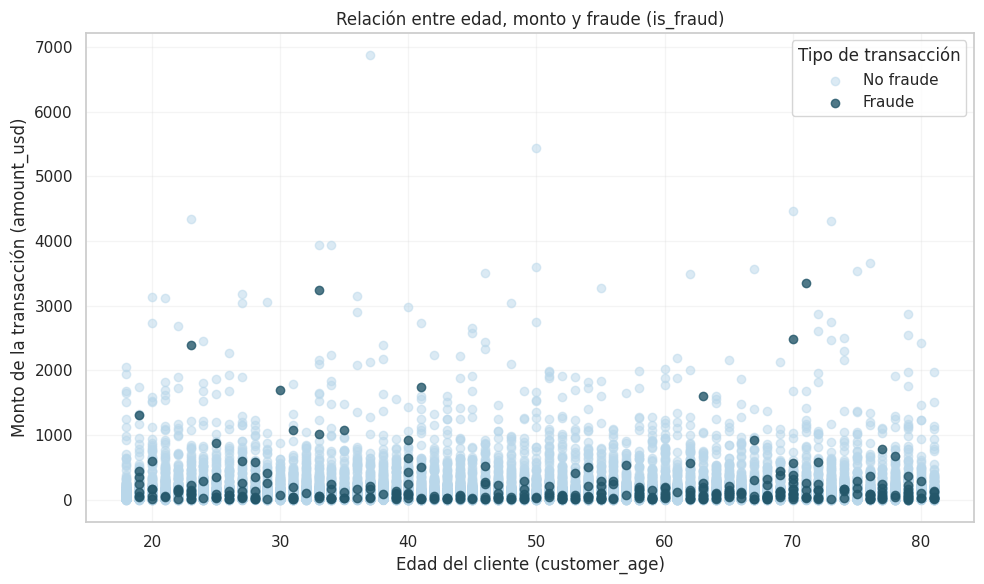

In [ ]:
import matplotlib.pyplot as plt

colores = ["#B9D7EA", "#24576A"]

plt.figure(figsize=(10, 6))

plt.scatter(
    df_fraude.loc[df_fraude["is_fraud"] == False, "customer_age"],
    df_fraude.loc[df_fraude["is_fraud"] == False, "amount_usd"],
    color=colores[0],
    alpha=0.5,
    label="No fraude"
)

plt.scatter(
    df_fraude.loc[df_fraude["is_fraud"] == True, "customer_age"],
    df_fraude.loc[df_fraude["is_fraud"] == True, "amount_usd"],
    color=colores[1],
    alpha=0.8,
    label="Fraude"
)

plt.xlabel("Edad del cliente (customer_age)")
plt.ylabel("Monto de la transacción (amount_usd)")
plt.title("Relación entre edad, monto y fraude (is_fraud)")

plt.legend(title="Tipo de transacción")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

No se observa una relación significativa entre el monto de la transacción, la edad del cliente y el fraude. La correlación entre el monto y el fraude es de 0,02, mientras que entre la edad y el fraude también es de 0,02. Además, el gráfico muestra que los casos de fraude están distribuidos entre diferentes edades y montos, sin una concentración clara.

**12. Porcentaje de fraude según el método de autenticación**

In [ ]:
#porcentaje de fraude según el método de autenticación

resultado_auth = pd.crosstab(
    df_fraude["auth_method"],
    df_fraude["is_fraud"],
    normalize="index"
)[True] * 100

resultado_auth = resultado_auth.round(2)

resultado_auth

,True
auth_method,
3D Secure,1.55
Biometric,0.78
No Authentication,4.44
OTP,1.57
PIN,1.15


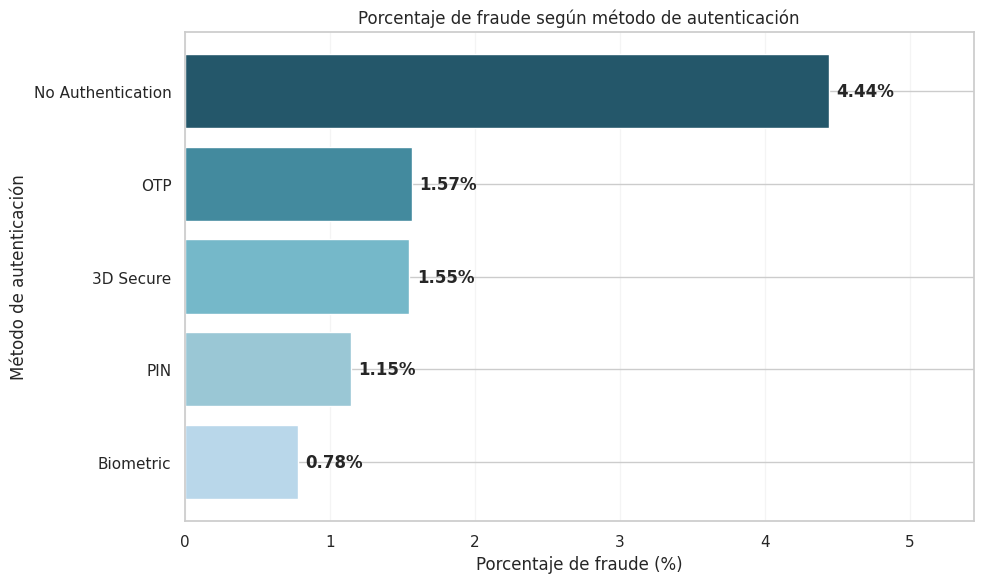

In [ ]:
import matplotlib.pyplot as plt

resultado_auth = resultado_auth.sort_values()

colores = [
    "#B9D7EA",
    "#9AC7D5",
    "#75B8C9",
    "#438A9E",
    "#24576A"
]

import matplotlib.pyplot as plt

resultado_auth = resultado_auth.sort_values()

colores = [
    "#B9D7EA",
    "#9AC7D5",
    "#75B8C9",
    "#438A9E",
    "#24576A"
]

plt.figure(figsize=(10, 6))

barras = plt.barh(
    resultado_auth.index,
    resultado_auth.values,
    color=colores
)

plt.xlabel("Porcentaje de fraude (%)")
plt.ylabel("Método de autenticación")
plt.title("Porcentaje de fraude según método de autenticación")

for barra, valor in zip(barras, resultado_auth.values):
    plt.text(
        barra.get_width() + 0.05,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontweight="bold"
    )

plt.xlim(0, resultado_auth.max() + 1)
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.show()

El porcentaje de fraude varía según el método de autenticación. “No Authentication” presenta el mayor porcentaje de fraude, con 4,44 %, mientras que “Biometric” presenta el menor, con 0,78 %. Los demás métodos se encuentran entre estos valores, mostrando diferencias en el porcentaje de fraude según el método utilizado.

**13. Variable de categoria de mercado, fraude y monto (SQL)**

In [ ]:
#Variable de categoria de mercado, fraude y monto (SQL)


resultado_mercado = df_fraude.groupby(
    ["merchant_category", "is_fraud"]
)["amount_usd"].mean().reset_index().round(2)

resultado_mercado

/tmp/ipykernel_4164/3272830355.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultado_mercado = df_fraude.groupby(


,merchant_category,is_fraud,amount_usd
0,Crypto Exchange,False,349.32
1,Crypto Exchange,True,506.59
2,Electronics,False,302.67
3,Electronics,True,279.18
4,Fuel,False,53.59
5,Fuel,True,65.51
6,Gaming,False,80.09
7,Gaming,True,172.47
8,Gift Cards,False,88.09
9,Gift Cards,True,111.20


In [ ]:
duckdb.sql("""
SELECT
    merchant_category,
    is_fraud,
    ROUND(AVG(amount_usd), 2) AS monto_promedio
FROM df_fraude
GROUP BY merchant_category, is_fraud
ORDER BY merchant_category, is_fraud
""")

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────┬────────────────┐
│                                                                           merchant_category                                                                           │ is_fraud │ monto_promedio │
│ enum('crypto exchange', 'electronics', 'fuel', 'gaming', 'gift cards', 'groceries', 'healthcare', 'online retail', 'restaurants', 'streaming', 'travel', 'utilities') │ boolean  │     double     │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼────────────────┤
│ Crypto Exchange                                                                                                                                                       │ false    │         349.32 │
│ Crypto E

El monto promedio de las transacciones fraudulentas varía según la categoría de mercado. En la mayoría de las categorías, las transacciones fraudulentas presentan un monto promedio mayor que las no fraudulentas, especialmente en Travel, Crypto Exchange y Gaming. Sin embargo, existen excepciones como Electronics y Healthcare, donde el monto promedio de las transacciones fraudulentas es menor.

**14. Variable de categoría de mercado, fraude y día de la semana**

In [ ]:
# Variable de categoría de mercado, fraude y día de la semana

dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

df_fraude["dia"] = df_fraude["day_of_week"].map(dias)

tabla_dia = pd.crosstab(
    df_fraude["merchant_category"],
    df_fraude["dia"],
    values=df_fraude["is_fraud"],
    aggfunc="mean"
) * 100

tabla_dia.round(2)

dia,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
merchant_category,,,,,,,
Crypto Exchange,5.68,3.53,5.32,4.55,8.45,4.44,2.99
Electronics,2.16,1.52,3.53,1.87,2.98,2.49,2.06
Fuel,2.69,0.91,1.36,0.89,0.00,1.89,0.82
Gaming,3.12,5.41,1.94,3.52,1.45,3.62,6.45
Gift Cards,7.23,5.75,3.37,9.30,1.28,2.70,1.67
Groceries,0.67,0.91,1.50,0.88,1.05,1.04,2.51
Healthcare,1.08,1.74,1.15,1.18,1.08,1.61,1.23
Online Retail,0.43,0.98,0.41,1.02,1.17,0.85,1.67
Restaurants,1.06,1.06,0.57,1.37,1.10,1.48,1.40


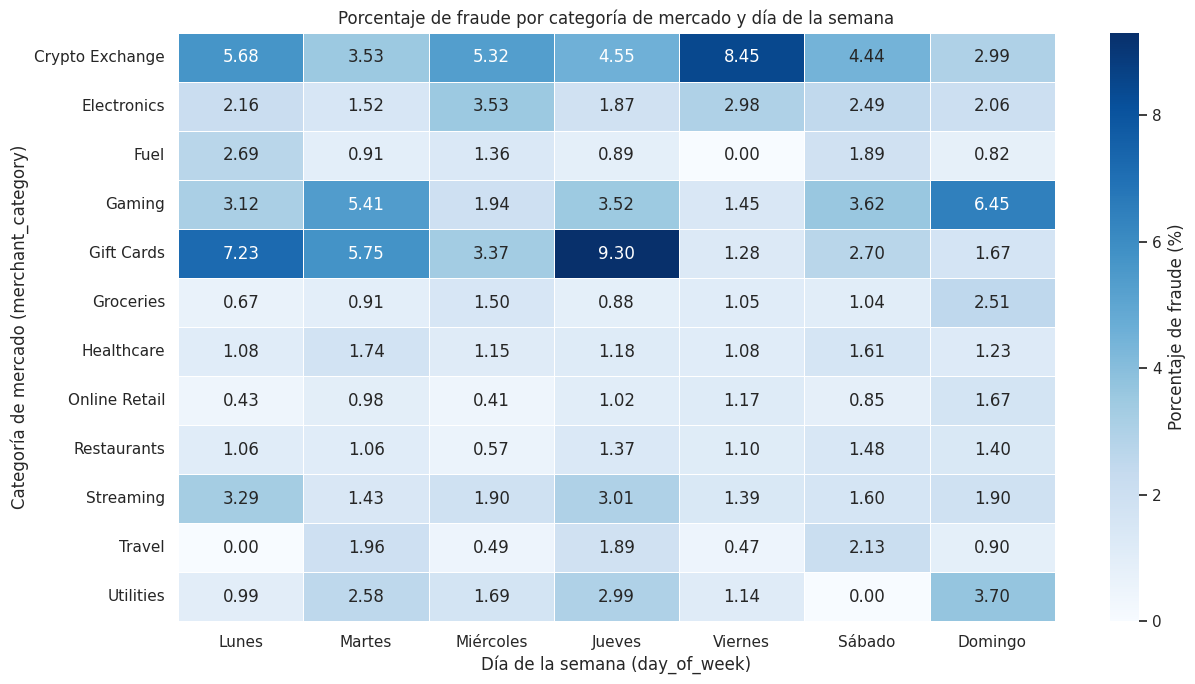

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13, 7))

sns.heatmap(
    tabla_dia,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Porcentaje de fraude (%)"}
)

plt.xlabel("Día de la semana (day_of_week)")
plt.ylabel("Categoría de mercado (merchant_category)")
plt.title("Porcentaje de fraude por categoría de mercado y día de la semana")

plt.tight_layout()
plt.show()

El porcentaje de fraude varía según la categoría de mercado y el día de la semana. Los valores más altos se presentan en combinaciones específicas, como Gift Cards los jueves (9,30 %), Crypto Exchange los viernes (8,45 %) y Gaming los domingos (6,45 %). También se observan porcentajes bajos o incluso de 0 % en algunas combinaciones, como Fuel los viernes y Utilities los sábados. Esto indica que el comportamiento del fraude cambia según la combinación entre categoría de mercado y día de la semana.

**15. Antiguedad de la tarjeta vs fraude vs monto**

Se identifican dos patrones diferentes. Las tarjetas de menor antigüedad tienen la mayor tasa de fraude, con un 2%, pero no son las que presentan los mayores montos fraudulentos. El mayor monto mediano de fraude aparece en Q3, con 82,30 dólares. Por eso, la antigüedad parece relacionarse de manera diferente con la frecuencia del fraude y con el valor de las transacciones.




In [ ]:
#Distribución de la variable de Antiguedad
df_fraude['card_age_months'].describe()

,card_age_months
count,20000.000000
mean,46.937550
std,6.768577
min,22.000000
25%,42.000000
50%,47.000000
75%,51.000000
max,74.000000


In [ ]:
#Comparación de la distribución Antiguaedad vs Fraude
df_fraude.groupby('is_fraud')['card_age_months'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,19661.0,46.948273,6.772515,22.0,42.0,47.0,51.0,74.0
True,339.0,46.315634,6.515622,26.0,41.0,46.0,51.0,68.0


Descriptivamente, las transacciones fraudulentas presentan una antigüedad de tarjeta ligeramente menor que las transacciones no fraudulentas; sin embargo, las distribuciones son muy similares, por lo que esta diferencia por sí sola no evidencia una asociación fuerte entre antigüedad y fraude.

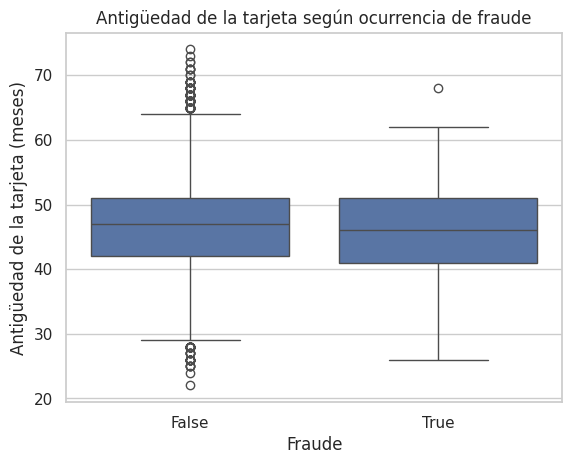

In [ ]:
sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='card_age_months'
)

plt.xlabel('Fraude')
plt.ylabel('Antigüedad de la tarjeta (meses)')
plt.title('Antigüedad de la tarjeta según ocurrencia de fraude')
plt.show()

Las antigüedades de las tarjetas fraudulentas y no fraudulentas son muy similares y se encuentran dentro de rangos ampliamente compartidos.

In [ ]:
#Crear la variable de rangos de Antiguedad por Cuartiles
df_fraude['card_age_quartile'] = pd.qcut(
    df_fraude['card_age_months'],
    q=4,
    labels=['Q1 - Menor antigüedad',
            'Q2 - Antigüedad baja-media',
            'Q3 - Antigüedad media-alta',
            'Q4 - Mayor antigüedad']
)

In [ ]:
#Identificar la tasa de fraude para cada grupo de Antiguedad
tabla_antiguedad = pd.crosstab(
    df_fraude['card_age_quartile'],
    df_fraude['is_fraud']
)

tabla_antiguedad['Tasa_fraude_%'] = (
    tabla_antiguedad[True] /
    tabla_antiguedad.sum(axis=1) * 100
).round(1)

tabla_antiguedad

is_fraud,False,True,Tasa_fraude_%
card_age_quartile,,,
Q1 - Menor antigüedad,5128,104,2.0
Q2 - Antigüedad baja-media,5488,90,1.6
Q3 - Antigüedad media-alta,4166,62,1.5
Q4 - Mayor antigüedad,4879,83,1.7


En este conjunto de datos, las transacciones correspondientes al cuartil de menor antigüedad presentan la mayor tasa de fraude observada (2,0 %), mientras que el cuartil de antigüedad media-alta presenta la menor (1,5 %). Esto sugiere una posible asociación entre la antigüedad de la tarjeta y la ocurrencia de fraude, aunque las diferencias observadas son relativamente pequeñas y no permiten establecer causalidad.

In [ ]:
#Incluir la Variable de Monto
df_fraude['amount_usd'].describe().round(2)

,amount_usd
count,20000.00
mean,132.42
std,256.96
min,1.00
25%,26.24
50%,57.51
75%,131.75
max,6872.69


In [ ]:
#Comparar la variable de monto vs fraude
df_fraude.groupby('is_fraud')['amount_usd'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,19661.0,131.58,254.24,1.00,26.21,57.35,130.88,6872.69
True,339.0,181.25,380.46,4.09,28.62,69.77,165.32,3356.46


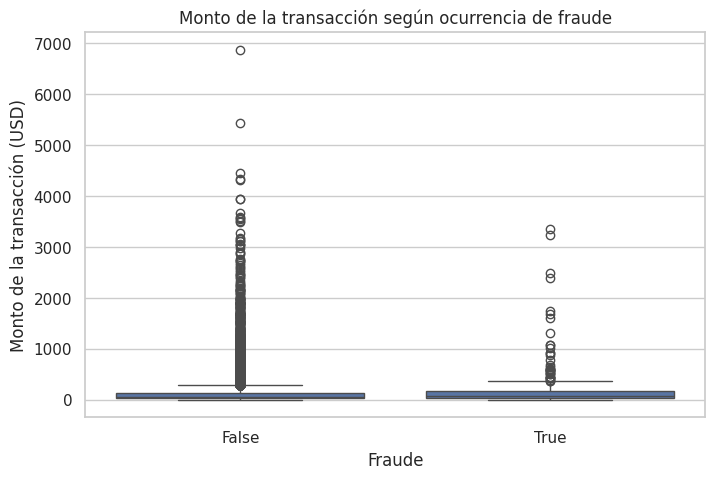

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='amount_usd'
)

plt.xlabel('Fraude')
plt.ylabel('Monto de la transacción (USD)')
plt.title('Monto de la transacción según ocurrencia de fraude')
plt.show()

In [ ]:
#Distribución de las 3 variables juntas
tabla_monto_antiguedad = pd.pivot_table(
    df_fraude,
    values='amount_usd',
    index='card_age_quartile',
    columns='is_fraud',
    aggfunc='median'
)

tabla_monto_antiguedad

/tmp/ipykernel_4164/317765867.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_monto_antiguedad = pd.pivot_table(


is_fraud,False,True
card_age_quartile,,
Q1 - Menor antigüedad,55.865,62.765
Q2 - Antigüedad baja-media,55.940,65.540
Q3 - Antigüedad media-alta,57.810,82.300
Q4 - Mayor antigüedad,60.730,58.710


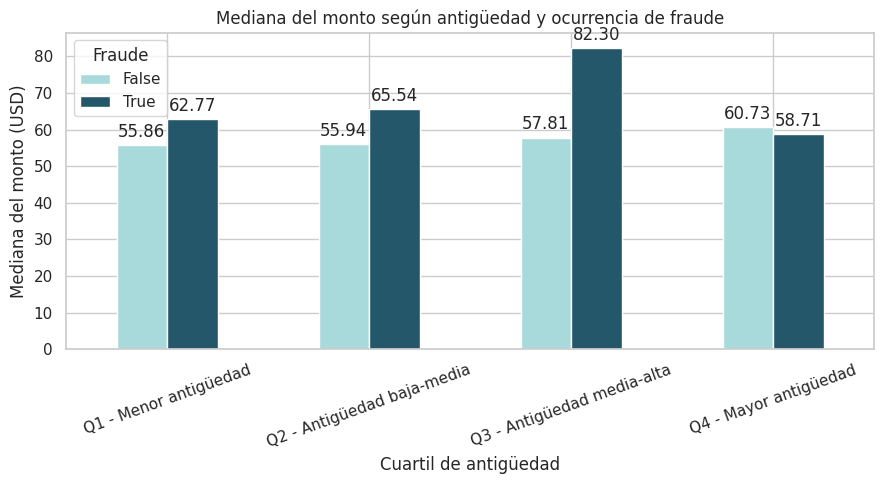

In [ ]:
ax = tabla_monto_antiguedad.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#A8DADC', '#24576A']  # azul claro, rosado pastel
)

plt.xlabel('Cuartil de antigüedad')
plt.ylabel('Mediana del monto (USD)')
plt.title('Mediana del monto según antigüedad y ocurrencia de fraude')
plt.xticks(rotation=20)
plt.legend(title='Fraude')

# Etiquetas de valor sobre cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

Se identifican dos patrones diferentes. Las tarjetas de menor antigüedad tienen la mayor tasa de fraude, con un 2%, pero no son las que presentan los mayores montos fraudulentos. El mayor monto mediano de fraude aparece en Q3, con 82,30 dólares. Por eso, la antigüedad parece relacionarse de manera diferente con la frecuencia del fraude y con el valor de las transacciones.

**16. Tipo de dispositivo vs fraude vs categoria de mercado**

La tasa de fraude presenta diferencias según la combinación entre tipo de dispositivo y categoría de mercado. Las tasas más elevadas se observan principalmente en Electronics para Android, POS Terminal e iPhone, mientras que Online Retail presenta tasas relativamente bajas en varios dispositivos. Esto sugiere que la combinación entre dispositivo y categoría de mercado puede aportar información relevante para la identificación de transacciones potencialmente fraudulentas.

In [ ]:
df_fraude['device_type'].value_counts()

,count
device_type,
Android Phone,5503
iPhone,4179
POS Terminal,3162
Windows PC,2623
Mac,1359
Tablet,1161
Smart Watch,1008
ATM Machine,1005


In [ ]:
df_fraude['merchant_category'].value_counts()

,count
merchant_category,
Online Retail,3416
Groceries,3242
Restaurants,2534
Electronics,2032
Fuel,1565
Travel,1420
Utilities,1330
Healthcare,1237
Gaming,1036


In [ ]:
import numpy as np

top_4_devices = ['Android Phone', 'iPhone', 'POS Terminal', 'Windows PC']
top_4_markets = ['Online Retail', 'Groceries', 'Restaurants', 'Electronics']

df_fraude['device_group'] = np.where(
    df_fraude['device_type'].isin(top_4_devices),
    df_fraude['device_type'],
    'Otros'
)

df_fraude['market_group'] = np.where(
    df_fraude['merchant_category'].isin(top_4_markets),
    df_fraude['merchant_category'],
    'Otros'
)

In [ ]:
df_fraude['device_group'].value_counts()

,count
device_group,
Android Phone,5503
Otros,4533
iPhone,4179
POS Terminal,3162
Windows PC,2623


In [ ]:
df_fraude['market_group'].value_counts()

,count
market_group,
Otros,8776
Online Retail,3416
Groceries,3242
Restaurants,2534
Electronics,2032


In [ ]:
#Obtener Fraude y tasa de fraude
tabla_device_market = pd.crosstab(
    [df_fraude['device_group'], df_fraude['market_group']],
    df_fraude['is_fraud']
)

tabla_device_market['Tasa_fraude_%'] = (
    tabla_device_market[True] /
    tabla_device_market.sum(axis=1) * 100
).round(2)

tabla_device_market

is_fraud                     False  True  Tasa_fraude_%
device_group  market_group                             
Android Phone Electronics      526    15           2.77
              Groceries        885     7           0.78
              Online Retail    922    11           1.18
              Otros           2339    64           2.66
              Restaurants      727     7           0.95
Otros         Electronics      452    10           2.16
              Groceries        746    15           1.97
              Online Retail    755    10           1.31
              Otros           1962    36           1.80
              Restaurants      535    12           2.19
POS Terminal  Electronics      322     9           2.72
              Groceries        479     8           1.64
              Online Retail    564     3           0.53
              Otros           1366    30           2.15
              Restaurants      377     4           1.05
Windows PC    Electronics      265     3           1.12
              Groceries        421     3           0.71
              Online Retail    427     4           0.93
              Otros           1156    17           1.45
              Restaurants      325     2           0.61
iPhone        Electronics      419    11           2.56
              Groceries        671     7           1.03
              Online Retail    716     4           0.56
              Otros           1763    43           2.38
              Restaurants      541     4           0.73

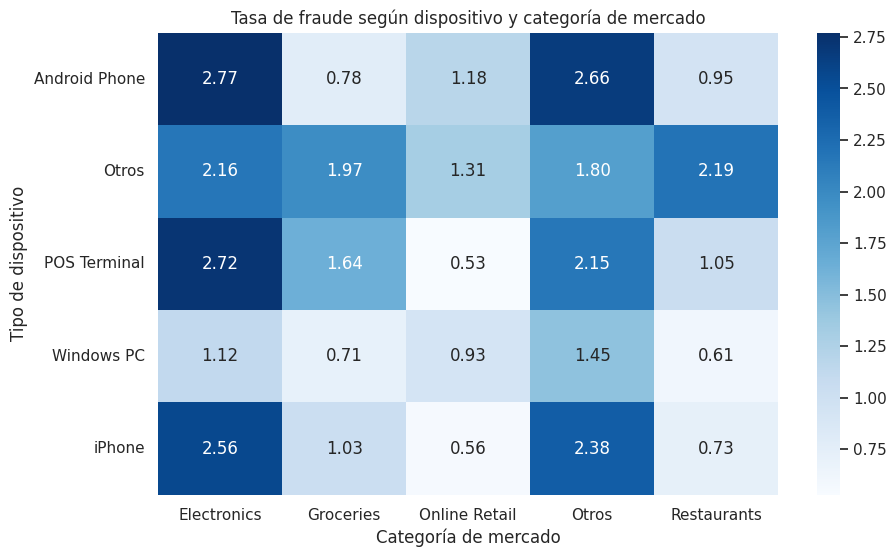

In [ ]:
#Visualizar la tasa de fraude
tabla_tasa = tabla_device_market['Tasa_fraude_%'].unstack()

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_tasa,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.xlabel('Categoría de mercado')
plt.ylabel('Tipo de dispositivo')
plt.title('Tasa de fraude según dispositivo y categoría de mercado')
plt.show()

La tasa de fraude presenta diferencias según la combinación entre tipo de dispositivo y categoría de mercado. Las tasas más elevadas se observan principalmente en Electronics para Android, POS Terminal e iPhone, mientras que Online Retail presenta tasas relativamente bajas en varios dispositivos. Esto sugiere que la combinación entre dispositivo y categoría de mercado puede aportar información relevante para la identificación de transacciones potencialmente fraudulentas.

**17. Mercado por primera vez vs categoria de mercado vs fraude**

Las transacciones realizadas en comercios nuevos presentan una tasa de fraude superior a las realizadas en comercios conocidos en todas las categorías analizadas. La diferencia es especialmente notable en Gift Cards, Gaming y Streaming, mientras que categorías como Fuel, Healthcare y Online Retail presentan tasas menores, aunque también muestran un incremento cuando el comercio es nuevo.

In [ ]:
#Generar tabla cruzada entre variables
tabla_new_merchant = pd.crosstab(
    [df_fraude['merchant_category'], df_fraude['is_new_merchant']],
    df_fraude['is_fraud']
)

tabla_new_merchant['Tasa_fraude_%'] = (
    tabla_new_merchant[True] /
    tabla_new_merchant.sum(axis=1) * 100
).round(2)

tabla_new_merchant

is_fraud                           False  True  Tasa_fraude_%
merchant_category is_new_merchant                            
Crypto Exchange   False              416    19           4.37
                  True               117     9           7.14
Electronics       False             1506    27           1.76
                  True               478    21           4.21
Fuel              False             1219     8           0.65
                  True               327    11           3.25
Gaming            False              794    22           2.70
                  True               204    16           7.27
Gift Cards        False              473    15           3.07
                  True               117    12           9.30
Groceries         False             2435    22           0.90
                  True               767    18           2.29
Healthcare        False              924     5           0.54
                  True               297    11           3.57
Online Retail     False             2618    10           0.38
                  True               766    22           2.79
Restaurants       False             1932    19           0.97
                  True               573    10           1.72
Streaming         False              757     9           1.17
                  True               232    12           4.92
Travel            False             1100    10           0.90
                  True               304     6           1.94
Utilities         False             1047    12           1.13
                  True               258    13           4.80

In [ ]:
#Código en SQL

query_1 = """
SELECT
    merchant_category,
    is_new_merchant,
    SUM(CASE WHEN is_fraud = FALSE THEN 1 ELSE 0 END) AS no_fraude,
    SUM(CASE WHEN is_fraud = TRUE THEN 1 ELSE 0 END) AS fraude,
    ROUND(
        100.0 * SUM(CASE WHEN is_fraud = TRUE THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS tasa_fraude_pct
FROM df_fraude
GROUP BY
    merchant_category,
    is_new_merchant
ORDER BY
    merchant_category,
    is_new_merchant
"""
sql_1 = run_sql(query_1)
sql_1


,merchant_category,is_new_merchant,no_fraude,fraude,tasa_fraude_pct
0,Crypto Exchange,0,416,19,4.37
1,Crypto Exchange,1,117,9,7.14
2,Electronics,0,1506,27,1.76
3,Electronics,1,478,21,4.21
4,Fuel,0,1219,8,0.65
5,Fuel,1,327,11,3.25
6,Gaming,0,794,22,2.70
7,Gaming,1,204,16,7.27
8,Gift Cards,0,473,15,3.07
9,Gift Cards,1,117,12,9.30


Un hallazgo rápido es que en todas las categorías de comercio, la tasa de fraude es mayor cuando is_new_merchant = True.

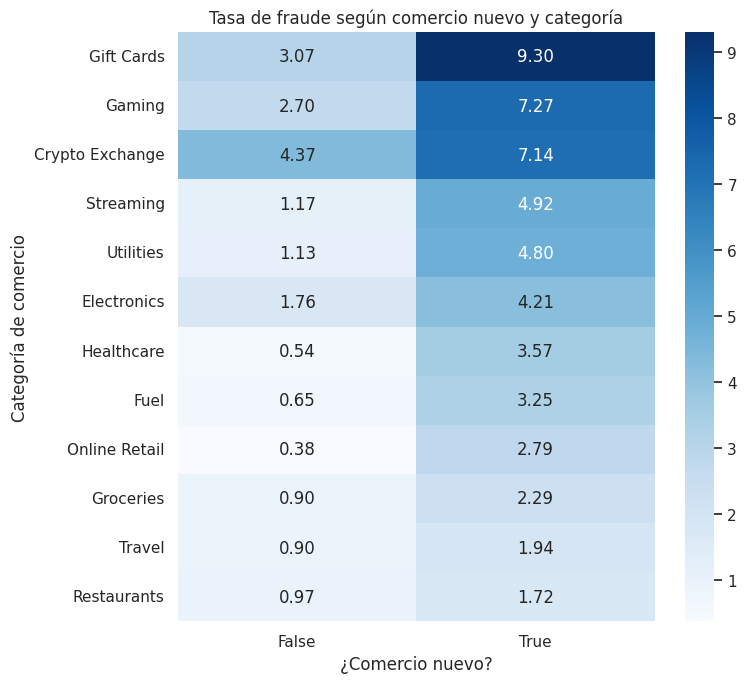

In [ ]:
tabla_new_merchant_heatmap = (
    tabla_new_merchant['Tasa_fraude_%']
    .unstack()
)

# Ordenar de mayor a menor según comercio nuevo
orden = tabla_new_merchant_heatmap[True].sort_values(
    ascending=False
).index

tabla_new_merchant_heatmap = tabla_new_merchant_heatmap.loc[orden]

plt.figure(figsize=(8, 7))

sns.heatmap(
    tabla_new_merchant_heatmap,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.xlabel('¿Comercio nuevo?')
plt.ylabel('Categoría de comercio')
plt.title('Tasa de fraude según comercio nuevo y categoría')

plt.tight_layout()
plt.show()

Las transacciones realizadas en comercios nuevos presentan una tasa de fraude superior a las realizadas en comercios conocidos en todas las categorías analizadas. La diferencia es especialmente notable en Gift Cards, Gaming y Streaming, mientras que categorías como Fuel, Healthcare y Online Retail presentan tasas menores, aunque también muestran un incremento cuando el comercio es nuevo.

## **18. Apoyo de IA vs fraude**

Las transacciones asociadas a intentos de estafa generados o apoyados por IA presentan una tasa de fraude de 9,07 %, frente al 1,55 % cuando no se identifica este componente. Esto representa una diferencia de 7,52 puntos porcentuales y una tasa aproximadamente 5,9 veces mayor. En este conjunto de datos, la variable presenta una asociación descriptiva marcada con la ocurrencia de fraude, aunque no permite establecer causalidad

In [ ]:
#Tabla Cruzada
tabla_ia_fraude = pd.crosstab(
    df_fraude['is_ai_generated_scam_attempt'],
    df_fraude['is_fraud']
)

tabla_ia_fraude['Tasa_fraude_%'] = (
    tabla_ia_fraude[True] /
    tabla_ia_fraude.sum(axis=1) * 100
).round(2)

tabla_ia_fraude

is_fraud,False,True,Tasa_fraude_%
is_ai_generated_scam_attempt,,,
False,19320,305,1.55
True,341,34,9.07


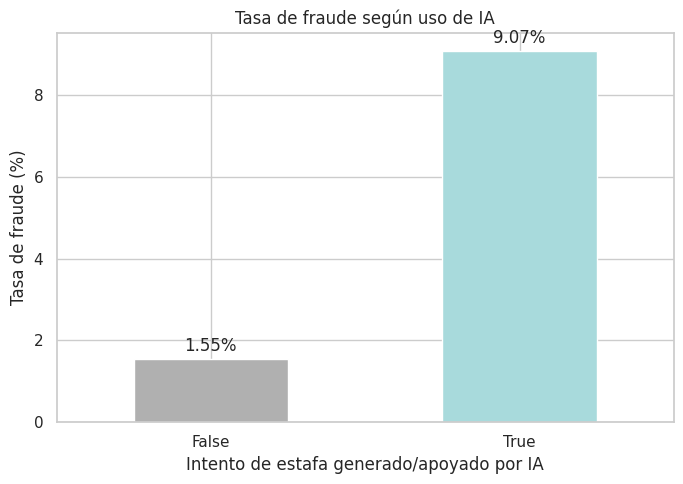

In [ ]:
tasa_ia = tabla_ia_fraude['Tasa_fraude_%']

ax = tasa_ia.plot(
    kind='bar',
    figsize=(7,5),
    color=['#B0B0B0', '#A8DADC']  # gris y azul claro
)

plt.xlabel('Intento de estafa generado/apoyado por IA')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude según uso de IA')
plt.xticks(rotation=0)

# Etiquetas de valor sobre cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

Las transacciones asociadas a intentos de estafa generados o apoyados por IA presentan una tasa de fraude de 9,07 %, frente al 1,55 % cuando no se identifica este componente. Esto representa una diferencia de 7,52 puntos porcentuales y una tasa aproximadamente 5,9 veces mayor. En este conjunto de datos, la variable presenta una asociación descriptiva marcada con la ocurrencia de fraude, aunque no permite establecer causalidad

## **19. Saldo de la cuenta usd vs fraude**

El saldo de la cuenta presenta una asociación leve con la ocurrencia de fraude. Las cuentas ubicadas en el cuartil de saldo alto presentan la mayor tasa de fraude (1,84%), mientras que las de saldo bajo presentan la menor (1,48%). Sin embargo, las diferencias entre los rangos son reducidas, por lo que el saldo por sí solo no muestra una separación marcada entre transacciones fraudulentas y no fraudulentas.

In [ ]:
#Resumen de las variables agrupadas
df_fraude.groupby('is_fraud')['account_balance_usd'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,19661.0,3314.17,4356.88,52.05,1017.48,2005.95,3941.03,127125.86
True,339.0,3461.50,3980.14,86.98,1090.30,2115.47,4215.84,30003.30


In [ ]:
#Crear grupos de Saldos por cuartiles y calculo de la Tasa de fraude según rango de saldo
df_fraude['balance_quartile'] = pd.qcut(
    df_fraude['account_balance_usd'],
    q=4,
    labels=['Q1 - Saldo bajo',
            'Q2 - Saldo bajo-medio',
            'Q3 - Saldo medio-alto',
            'Q4 - Saldo alto']
)

tabla_balance_fraude = pd.crosstab(
    df_fraude['balance_quartile'],
    df_fraude['is_fraud']
)

tabla_balance_fraude['Tasa_fraude_%'] = (
    tabla_balance_fraude[True] /
    tabla_balance_fraude.sum(axis=1) * 100
).round(2)

tabla_balance_fraude

is_fraud,False,True,Tasa_fraude_%
balance_quartile,,,
Q1 - Saldo bajo,4926,74,1.48
Q2 - Saldo bajo-medio,4911,89,1.78
Q3 - Saldo medio-alto,4916,84,1.68
Q4 - Saldo alto,4908,92,1.84


In [ ]:
#Código en SQL

query_1 = """
WITH datos AS (
    SELECT
        is_fraud,
        NTILE(4) OVER (
            ORDER BY account_balance_usd
        ) AS cuartil
    FROM df_fraude
),

tabla AS (
    SELECT
        cuartil,
        SUM(CASE WHEN is_fraud = FALSE THEN 1 ELSE 0 END) AS no_fraude,
        SUM(CASE WHEN is_fraud = TRUE THEN 1 ELSE 0 END) AS fraude,
        COUNT(*) AS total
    FROM datos
    GROUP BY cuartil
)

SELECT
    CASE
        WHEN cuartil = 1 THEN 'Q1 - Saldo bajo'
        WHEN cuartil = 2 THEN 'Q2 - Saldo bajo-medio'
        WHEN cuartil = 3 THEN 'Q3 - Saldo medio-alto'
        WHEN cuartil = 4 THEN 'Q4 - Saldo alto'
    END AS balance_quartile,

    no_fraude AS "False",
    fraude AS "True",

    ROUND(
        100.0 * fraude / total,
        2
    ) AS "Tasa_fraude_%"

FROM tabla
ORDER BY cuartil
"""
sql_1 = run_sql(query_1)
sql_1


,balance_quartile,False,True,Tasa_fraude_%
0,Q1 - Saldo bajo,4926,74,1.48
1,Q2 - Saldo bajo-medio,4911,89,1.78
2,Q3 - Saldo medio-alto,4916,84,1.68
3,Q4 - Saldo alto,4908,92,1.84


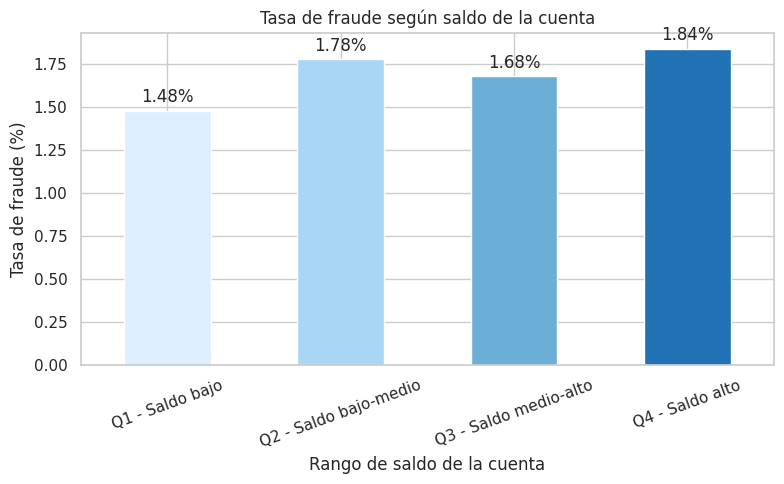

In [ ]:
ax = tabla_balance_fraude['Tasa_fraude_%'].plot(
    kind='bar',
    figsize=(8,5),
    color=['#DCEEFF', '#A9D6F5', '#6BAED6', '#2171B5']
)

plt.xlabel('Rango de saldo de la cuenta')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude según saldo de la cuenta')
plt.xticks(rotation=20)

# Etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

El saldo de la cuenta presenta una asociación leve con la ocurrencia de fraude. Las cuentas ubicadas en el cuartil de saldo alto presentan la mayor tasa de fraude (1,84%), mientras que las de saldo bajo presentan la menor (1,48%). Sin embargo, las diferencias entre los rangos son reducidas, por lo que el saldo por sí solo no muestra una separación marcada entre transacciones fraudulentas y no fraudulentas.

## **20. Velocidad vs horas desde la última compra vs fraude**

El velocity_score muestra una diferencia más marcada entre transacciones fraudulentas y no fraudulentas, mientras que hours_since_last_txn presenta una diferencia más moderada. En conjunto, una mayor velocidad de transacciones y un menor tiempo desde la transacción anterior aparecen asociados con una mayor ocurrencia de fraude. Estos patrones son descriptivos y no implican causalidad.

In [ ]:
#Resumen de la variable por fraude
df_fraude.groupby('is_fraud')[['velocity_score', 'hours_since_last_txn']].describe().round(2)

velocity_score                                             hours_since_last_txn                                            
                  count   mean    std  min    25%   50%   75%   max                count  mean   std   min   25%   50%    75%    max
is_fraud                                                                                                                            
False           19661.0  19.65  12.28  0.0  10.60  18.7  27.5  74.4              19661.0  8.98  8.85  0.01  2.61  6.23  12.48  87.05
True              339.0  28.97  13.71  0.0  18.45  27.7  37.7  71.5                339.0  7.01  7.64  0.01  1.52  4.27  10.00  48.12

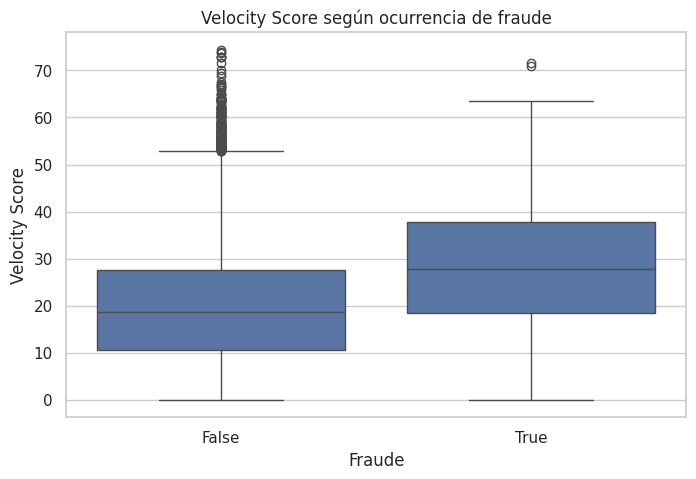

In [ ]:
#Conparación visual
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='velocity_score'
)
plt.xlabel('Fraude')
plt.ylabel('Velocity Score')
plt.title('Velocity Score según ocurrencia de fraude')
plt.show()

El grupo de transacciones fraudulentas presenta valores de velocity_score generalmente más altos que las no fraudulentas. La mediana aumenta de 18,7 a 27,7 y el rango central también se desplaza hacia valores superiores. Esto sugiere una asociación entre una mayor velocidad de transacciones y la ocurrencia de fraude.

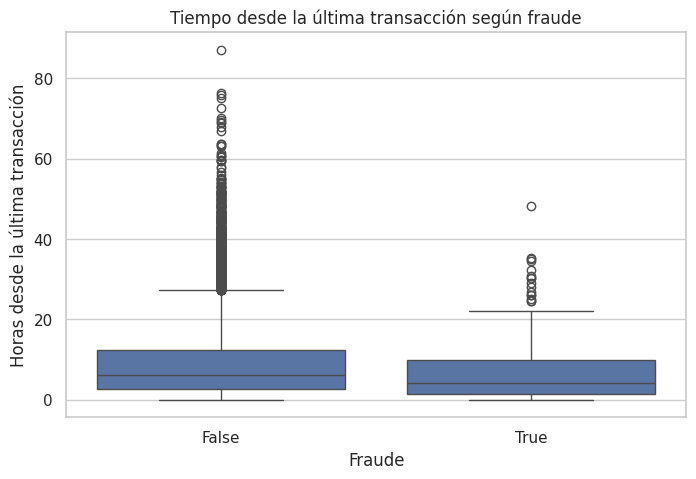

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='hours_since_last_txn'
)
plt.xlabel('Fraude')
plt.ylabel('Horas desde la última transacción')
plt.title('Tiempo desde la última transacción según fraude')
plt.show()

Las transacciones fraudulentas presentan un tiempo ligeramente menor desde la última transacción. La mediana pasa de 6,23 horas en las no fraudulentas a 4,27 horas en las fraudulentas. Esto indica que, en este conjunto de datos, las transacciones realizadas con menor intervalo respecto a la anterior muestran una mayor asociación con el fraude.

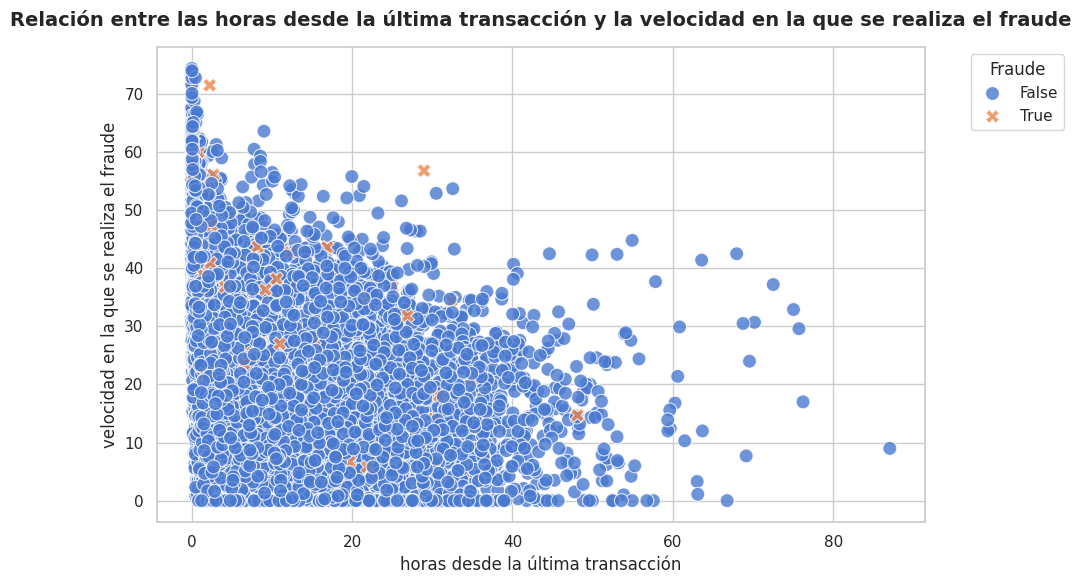

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data= df_fraude,
    x="hours_since_last_txn",
    y="velocity_score",
    hue="is_fraud",      # Color por especie
    style="is_fraud",    # Marcador diferente por especie
    s=100,              # Tamaño de los puntos
    alpha=0.8
)

# 4. Personalizar textos y diseño corporativo
plt.title("Relación entre las horas desde la última transacción y la velocidad en la que se realiza el fraude", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("horas desde la última transacción", fontsize=12)
plt.ylabel("velocidad en la que se realiza el fraude", fontsize=12)
plt.legend(title="Fraude", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar y mostrar limpio
plt.tight_layout()
plt.show()

El velocity_score muestra una diferencia más marcada entre transacciones fraudulentas y no fraudulentas, mientras que hours_since_last_txn presenta una diferencia más moderada. En conjunto, una mayor velocidad de transacciones y un menor tiempo desde la transacción anterior aparecen asociados con una mayor ocurrencia de fraude. Estos patrones son descriptivos y no implican causalidad.

## **21. Tipo de dispositivo vs Apoyo IA vs fraude**

La presencia de un intento de estafa generado o apoyado por IA se asocia con una mayor tasa de fraude en todos los tipos de dispositivo analizados. La diferencia es especialmente marcada en Android Phone, donde la tasa aumenta de 1,65% a 13,39%. Esto sugiere que combinar el tipo de dispositivo con esta variable puede aportar información relevante para la identificación temprana de transacciones potencialmente fraudulentas.

In [ ]:
#Agrupamiento de variables

tabla_device_ia = pd.crosstab(
    [df_fraude['device_group'],
     df_fraude['is_ai_generated_scam_attempt']],
    df_fraude['is_fraud']
)

tabla_device_ia['Tasa_fraude_%'] = (
    tabla_device_ia[True] /
    tabla_device_ia.sum(axis=1) * 100
).round(2)

tabla_device_ia

is_fraud                                    False  True  Tasa_fraude_%
device_group  is_ai_generated_scam_attempt                            
Android Phone False                          5302    89           1.65
              True                             97    15          13.39
Otros         False                          4384    78           1.75
              True                             66     5           7.04
POS Terminal  False                          3051    50           1.61
              True                             57     4           6.56
Windows PC    False                          2548    25           0.97
              True                             46     4           8.00
iPhone        False                          4035    63           1.54
              True                             75     6           7.41

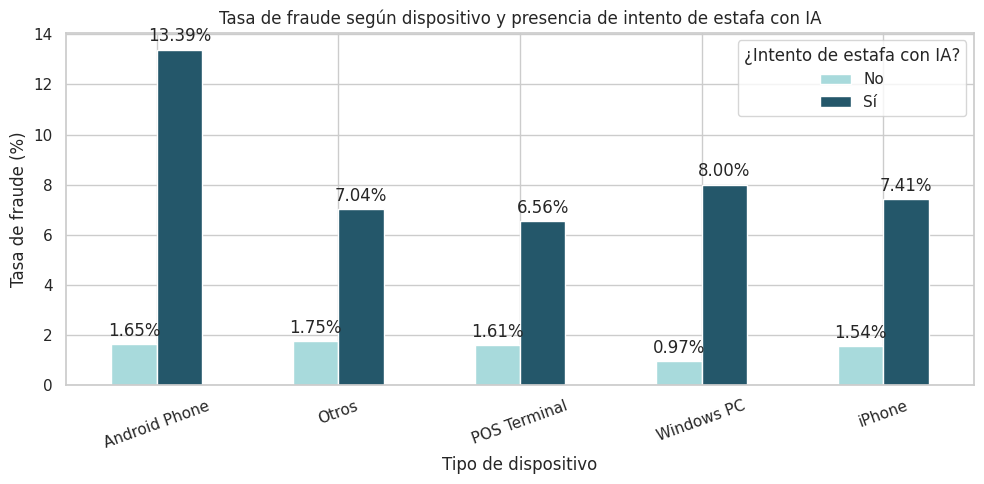

In [ ]:
tabla_tasa_device_ia = (
    tabla_device_ia['Tasa_fraude_%']
    .unstack()
)

ax = tabla_tasa_device_ia.plot(
    kind='bar',
    figsize=(10,5),
    color=['#A8DADC', '#24576A']  # azul claro y azul oscuro
)

plt.xlabel('Tipo de dispositivo')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude según dispositivo y presencia de intento de estafa con IA')
plt.xticks(rotation=20)

plt.legend(
    title='¿Intento de estafa con IA?',
    labels=['No', 'Sí']
)

# Etiquetas sobre cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

El patrón es bastante claro: en todos los tipos de dispositivo, la tasa de fraude es mayor cuando se identifica un intento de estafa con IA.

La presencia de un intento de estafa generado o apoyado por IA se asocia con una mayor tasa de fraude en todos los tipos de dispositivo analizados. La diferencia es especialmente marcada en Android Phone, donde la tasa aumenta de 1,65% a 13,39%. Esto sugiere que combinar el tipo de dispositivo con esta variable puede aportar información relevante para la identificación temprana de transacciones potencialmente fraudulentas.